# TPE331 Modelica Transition Plan and Training
This notebook is a training guide to migrate the current turboprop Modelica model to a TPE331-oriented model.

Outputs:
- Practical migration plan (phased)
- Validation checklist and acceptance criteria
- Session-by-session training script

## 1) Target Architecture (what will change)
1. Compressor: replace/retune map scaling to TPE331 target.
2. Turbine: include two-map structure (GGT + FPT) and scale each map.
3. Shaft coupling: align gas-generator and power-turbine dynamics.
4. Fuel/control block: update schedule to match TPE331 operation envelope.
5. Validation harness: add map-level and cycle-level acceptance tests.

In [1]:
import pandas as pd

plan_rows = [
    {"Phase": "P0", "Goal": "Baseline freeze", "Tasks": "Freeze current model, map files, and KPIs", "Deliverable": "Baseline package", "DoD": "Reproducible baseline run"},
    {"Phase": "P1", "Goal": "Compressor migration", "Tasks": "Apply TPE331 compressor scaling and wire to Modelica map block", "Deliverable": "Scaled compressor map", "DoD": "Design-point PR/flow/eta within tolerance"},
    {"Phase": "P2", "Goal": "Turbine migration", "Tasks": "Scale GGT/FPT XML maps and connect turbine blocks", "Deliverable": "Scaled turbine maps (GGT/FPT)", "DoD": "Stable turbine operating lines"},
    {"Phase": "P3", "Goal": "Cycle integration", "Tasks": "Re-tune shaft/load/nozzle interactions", "Deliverable": "Integrated TPE331 cycle model", "DoD": "No algebraic failure and stable transient"},
    {"Phase": "P4", "Goal": "Control adaptation", "Tasks": "Update fuel schedule, governor, limiters", "Deliverable": "Control-calibrated model", "DoD": "Step response and limit behavior pass"},
    {"Phase": "P5", "Goal": "Verification", "Tasks": "Run design/off-design sweeps and compare reference bands", "Deliverable": "Verification report", "DoD": "All acceptance criteria pass"},
]

plan_df = pd.DataFrame(plan_rows)
plan_df

,Phase,Goal,Tasks,Deliverable,DoD
0,P0,Baseline freeze,"Freeze current model, map files, and KPIs",Baseline package,Reproducible baseline run
1,P1,Compressor migration,Apply TPE331 compressor scaling and wire to Mo...,Scaled compressor map,Design-point PR/flow/eta within tolerance
2,P2,Turbine migration,Scale GGT/FPT XML maps and connect turbine blocks,Scaled turbine maps (GGT/FPT),Stable turbine operating lines
3,P3,Cycle integration,Re-tune shaft/load/nozzle interactions,Integrated TPE331 cycle model,No algebraic failure and stable transient
4,P4,Control adaptation,"Update fuel schedule, governor, limiters",Control-calibrated model,Step response and limit behavior pass
5,P5,Verification,Run design/off-design sweeps and compare refer...,Verification report,All acceptance criteria pass


## 2) Acceptance Criteria
Use these gates before claiming migration complete:
1. Map-level consistency:
   - Compressor and turbine design anchors are hit after scaling.
   - No non-physical map zones (negative efficiency, invalid PR).
2. Solver robustness:
   - No persistent initialization failures.
   - No unstable oscillation under nominal load steps.
3. Performance plausibility:
   - Power, flow, and key temperatures remain within expected range.
4. Traceability:
   - Every tuning value is logged with reason and evidence.

In [ ]:
checklist = [
    ("Compressor map scaled and wired", False),
    ("GGT map scaled and wired", False),
    ("FPT map scaled and wired", False),
    ("Shaft dynamics re-tuned", False),
    ("Fuel/governor schedule updated", False),
    ("Design point validation pass", False),
    ("Off-design sweep pass", False),
    ("Documentation and evidence pack ready", False),
]

check_df = pd.DataFrame(checklist, columns=["Item", "Done"])
check_df

## 3) Training Program (4 sessions)
### Session A - Map fundamentals and scaling
- Explain corrected vs actual flow.
- Re-run compressor and turbine scaling cells.
- Confirm design-anchor matching.

### Session B - Modelica block migration
- Replace map sources in Modelica blocks.
- Verify parameter wiring and package.order integrity.
- Run quick compile and initialization checks.

### Session C - Dynamics and controls
- Tune shaft inertia/load coupling and governor/fuel logic.
- Run transient scenarios (load step, fuel ramp).

### Session D - Verification and report
- Execute acceptance checklist.
- Capture plots/tables and create final migration report.

In [ ]:
session_plan = pd.DataFrame(
    [
        {"Session": "A", "Topic": "Map scaling", "Hands-on": "Run XML scaling and overlay plots", "Output": "Scaled map package"},
        {"Session": "B", "Topic": "Modelica wiring", "Hands-on": "Bind map tables to Modelica blocks", "Output": "Compilable migrated model"},
        {"Session": "C", "Topic": "Dynamics/control tuning", "Hands-on": "Tune transients and constraints", "Output": "Stable transient behavior"},
        {"Session": "D", "Topic": "Verification/report", "Hands-on": "Run sweeps and summarize evidence", "Output": "Validation report"},
    ]
)
session_plan

## 4) Practical Next Actions
1. In the map notebook, finalize TPE331 target values for compressor/GGT/FPT.
2. Export scaled maps to the format expected by the Modelica blocks.
3. Apply migration in small commits (map wiring, then control updates, then validation).
4. Use this notebook as the lecture script and sign-off checklist.

# Map Visualization 

## 5) TPE331 Map Visualization (turbomap utils)

패키지화된 유틸리티:
- `turbomap_data_utils.py` — XML 파싱 + 설계점 스케일링
  - `parse_compressor_xml(path)` / `parse_turbine_xml(path)`
  - `scale_compressor_map(parsed, target)` / `scale_turbine_map(parsed, target)`
- `turbomap_plot_utils.py` — 시각화 함수
  - `plot_compressor_map()` — 단독 맵 (surge/choke/rpm/eff contours)
  - `plot_compressor_overlay()` — base vs scaled 2-panel 비교

In [21]:
import sys, os, importlib
import numpy as np
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

import turbomap_data_utils, turbomap_plot_utils
importlib.reload(turbomap_data_utils)
importlib.reload(turbomap_plot_utils)

from turbomap_data_utils import parse_compressor_xml, scale_compressor_map, T_REF, P_REF
from turbomap_plot_utils import plot_compressor_map, plot_compressor_overlay

# ─── 1) XML 파싱 + TPE331 스케일링 ───
xml_cmp_path = r"C:\Users\user\Downloads\Turboprop_ggc.xml"

cmp_parsed = parse_compressor_xml(xml_cmp_path)
print(f"XML loaded: {cmp_parsed['path']}")
print(f"  Nc range: {cmp_parsed['nc'].min():.3f} ~ {cmp_parsed['nc'].max():.3f}")
print(f"  Design anchor: Nc={cmp_parsed['nc_des']:.4f}, Rline={cmp_parsed['rline_des']:.5f}")
print(f"  Wc_des={cmp_parsed['wc_des']:.4f}, PR_des={cmp_parsed['pr_des']:.4f}, eta_des={cmp_parsed['eta_des']:.4f}")

# TPE331 compressor target
TPE331_CMP = {
    "m_flow_des": 8.0,      # kg/s (actual)
    "PRdes": 10.0,           # pressure ratio
    "effDes": 0.82,          # efficiency
    "T1_des": 288.15,        # K
    "p1_des": 101325.0,      # Pa
}

scaled = scale_compressor_map(cmp_parsed, TPE331_CMP)
print(f"\n[Scale factors]")
print(f"  s_Wc(actual)={scaled['s_Wc_actual']:.6f}, s_Wc(corr)={scaled['s_Wc_corr']:.6f}")
print(f"  s_PR={scaled['s_PR']:.6f}, s_eff={scaled['s_eff']:.6f}")
print(f"  Wc target corrected={scaled['wc_target_corr']:.4f} kg/s")

# ─── Correction factor 진단 ───
corr_factor = np.sqrt(TPE331_CMP["T1_des"] / T_REF) / (TPE331_CMP["p1_des"] / P_REF)
print(f"\n[Correction factor diagnostic]")
print(f"  T1_des/T_REF = {TPE331_CMP['T1_des']:.2f}/{T_REF:.2f} = {TPE331_CMP['T1_des']/T_REF:.6f}")
print(f"  p1_des/P_REF = {TPE331_CMP['p1_des']:.1f}/{P_REF:.1f} = {TPE331_CMP['p1_des']/P_REF:.6f}")
print(f"  Wc_corr = m_dot × sqrt(T/Tref) / (P/Pref)  →  correction factor = {corr_factor:.6f}")
if abs(corr_factor - 1.0) < 1e-6:
    print(f"  ⚠️  correction factor ≈ 1.0 → Actual = Corrected (x축 스케일 동일)")
    print(f"      T1_des=T_REF, p1_des=P_REF 이므로 보정이 없습니다.")
    print(f"      고도/온도 조건이 ISA SL과 다르면 T1_des, p1_des를 변경하세요.")
else:
    print(f"  ✓ Actual ≠ Corrected — x축 스케일 차이 발생")

XML loaded: C:\Users\user\Downloads\Turboprop_ggc.xml
  Nc range: 0.500 ~ 1.050
  Design anchor: Nc=0.9500, Rline=0.52632
  Wc_des=31.0260, PR_des=7.6067, eta_des=0.8668

[Scale factors]
  s_Wc(actual)=0.257849, s_Wc(corr)=0.257849
  s_PR=1.362264, s_eff=0.945965
  Wc target corrected=8.0000 kg/s

[Correction factor diagnostic]
  T1_des/T_REF = 288.15/288.15 = 1.000000
  p1_des/P_REF = 101325.0/101325.0 = 1.000000
  Wc_corr = m_dot × sqrt(T/Tref) / (P/Pref)  →  correction factor = 1.000000
  ⚠️  correction factor ≈ 1.0 → Actual = Corrected (x축 스케일 동일)
      T1_des=T_REF, p1_des=P_REF 이므로 보정이 없습니다.
      고도/온도 조건이 ISA SL과 다르면 T1_des, p1_des를 변경하세요.


✓ plot_compressor_map() with real XML data


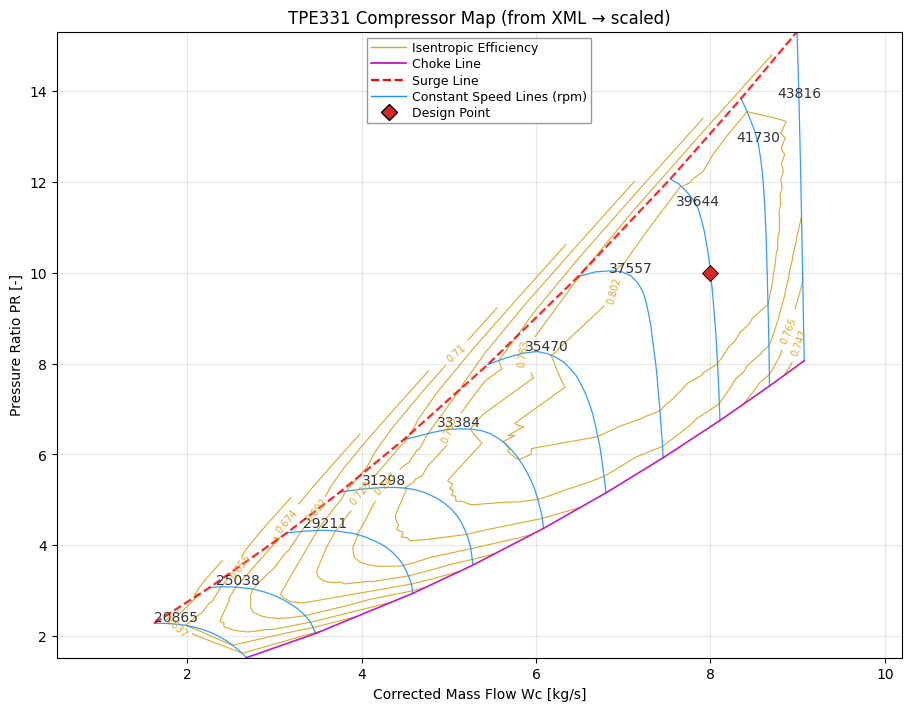

In [5]:
# ─── 2) 단독 컴프레서 맵 시각화 (Cell-40 style) ───
fig1, ax1 = plot_compressor_map(
    scaled["wc_scaled_corr"],
    scaled["pr_scaled"],
    scaled["eta_scaled"],
    scaled["nc"],
    NmechDes=41730.0,  # TPE331 gas generator ~41730 rpm
    design_point={"Wc": scaled["wc_target_corr"], "PR": TPE331_CMP["PRdes"]},
    title="TPE331 Compressor Map (from XML → scaled)",
)
print("✓ plot_compressor_map() with real XML data")

✓ plot_compressor_overlay() — base map hidden


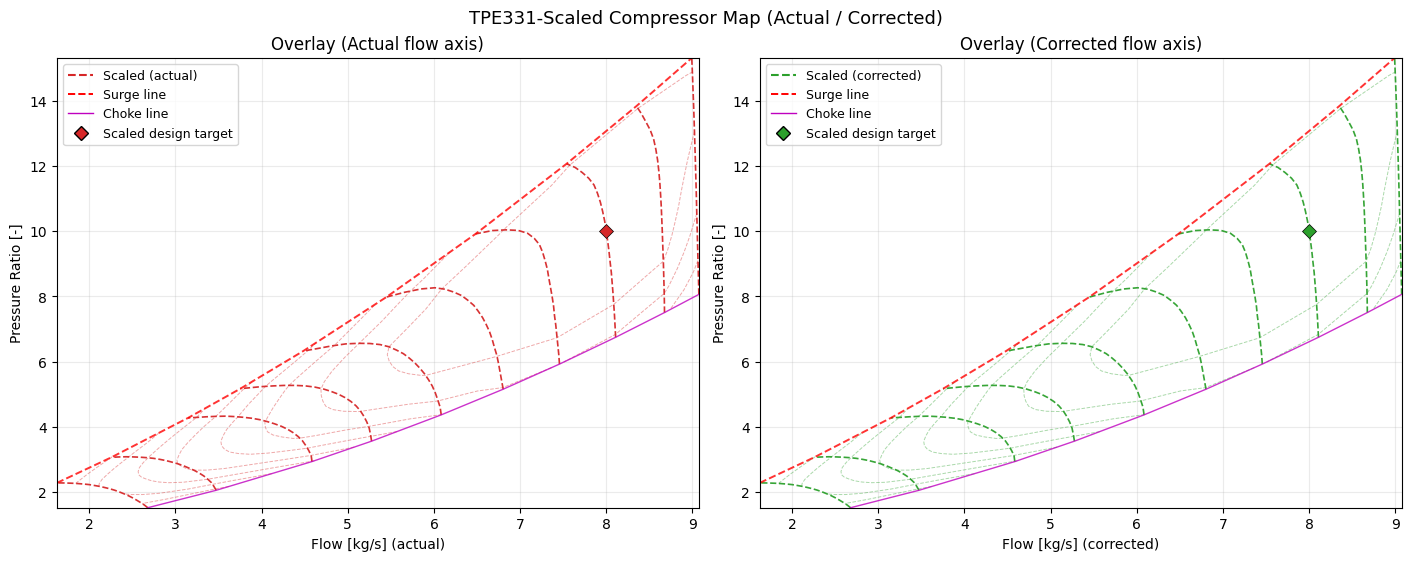

In [15]:
# ─── 3) Base vs Scaled 오버레이 (Cell-42 style) ───
# "Base" = XML 원본 맵 (unscaled), "Scaled" = TPE331으로 스케일된 맵
fig2, axes2 = plot_compressor_overlay(
    Wc_base=cmp_parsed["wc"],
    PR_base=cmp_parsed["pr"],
    Eta_base=cmp_parsed["eta"],
    Nc_base=cmp_parsed["nc"],
    Wc_scaled_actual=scaled["wc_scaled_actual"],
    Wc_scaled_corr=scaled["wc_scaled_corr"],
    PR_scaled=scaled["pr_scaled"],
    Eta_scaled=scaled["eta_scaled"],
    Nc_scaled=scaled["nc"],
    show_base=False,
    base_design=None,
    scaled_design_actual={"Wc": TPE331_CMP["m_flow_des"], "PR": TPE331_CMP["PRdes"]},
    scaled_design_corr={"Wc": scaled["wc_target_corr"], "PR": TPE331_CMP["PRdes"]},
    suptitle="TPE331-Scaled Compressor Map (Actual / Corrected)",
)
print("✓ plot_compressor_overlay() — base map hidden")

## 6) Turbine Map Visualization (GGT / FPT)

- `parse_turbine_xml(path)` → XML 파싱
- `scale_turbine_map(parsed, target)` → 설계점 스케일링
- `plot_turbine_maps_2x2(scaled_maps)` → 2×2 레이아웃 (상단=Wc, 하단=η; 좌=GGT, 우=FPT)

In [22]:
# ─── 4) Turbine XML 파싱 + TPE331 스케일링 (GGT / FPT) ───
importlib.reload(turbomap_data_utils)
importlib.reload(turbomap_plot_utils)

from turbomap_data_utils import parse_turbine_xml, scale_turbine_map
from turbomap_plot_utils import plot_turbine_maps_2x2

XML_TRB_PATHS = {
    "GGT": r"C:\Users\user\Downloads\Turboprop_ggt_Rline.xml",
    "FPT": r"C:\Users\user\Downloads\Turboprop_fpt_Rline.xml",
}

TPE331_TRB = {
    "GGT": {
        "m_flow_des": 8.0,       # kg/s
        "PRdes": 3.2,            # expansion ratio
        "effDes": 0.86,
        "T1_des": 1200.0,        # K (turbine inlet)
        "p1_des": 300000.0,      # Pa
    },
    "FPT": {
        "m_flow_des": 8.0,
        "PRdes": 1.8,
        "effDes": 0.88,
        "T1_des": 1000.0,
        "p1_des": 200000.0,
    },
}

scaled_trb = {}
for key, xml_path in XML_TRB_PATHS.items():
    parsed = parse_turbine_xml(xml_path)
    trg = TPE331_TRB[key]
    sc = scale_turbine_map(parsed, trg)
    sc["target"] = trg
    scaled_trb[key] = sc
    print(f"\n[{key}] XML: {parsed['path']}")
    print(f"  Nc range: {parsed['nc'].min():.3f} ~ {parsed['nc'].max():.3f}")
    print(f"  s_Wc_corr={sc['s_Wc_corr']:.4f}, s_PR={sc['s_PR']:.4f}, s_eff={sc['s_eff']:.4f}")
    print(f"  Wc_target_corr={sc['wc_target_corr']:.4f} kg/s")


[GGT] XML: C:\Users\user\Downloads\Turboprop_ggt_Rline.xml
  Nc range: 0.600 ~ 1.100
  s_Wc_corr=1.7670, s_PR=1.3086, s_eff=0.9445
  Wc_target_corr=5.5140 kg/s

[FPT] XML: C:\Users\user\Downloads\Turboprop_fpt_Rline.xml
  Nc range: 0.200 ~ 1.300
  s_Wc_corr=0.3771, s_PR=0.3957, s_eff=0.9570
  Wc_target_corr=7.5504 kg/s


✓ plot_turbine_maps_2x2() — GGT + FPT


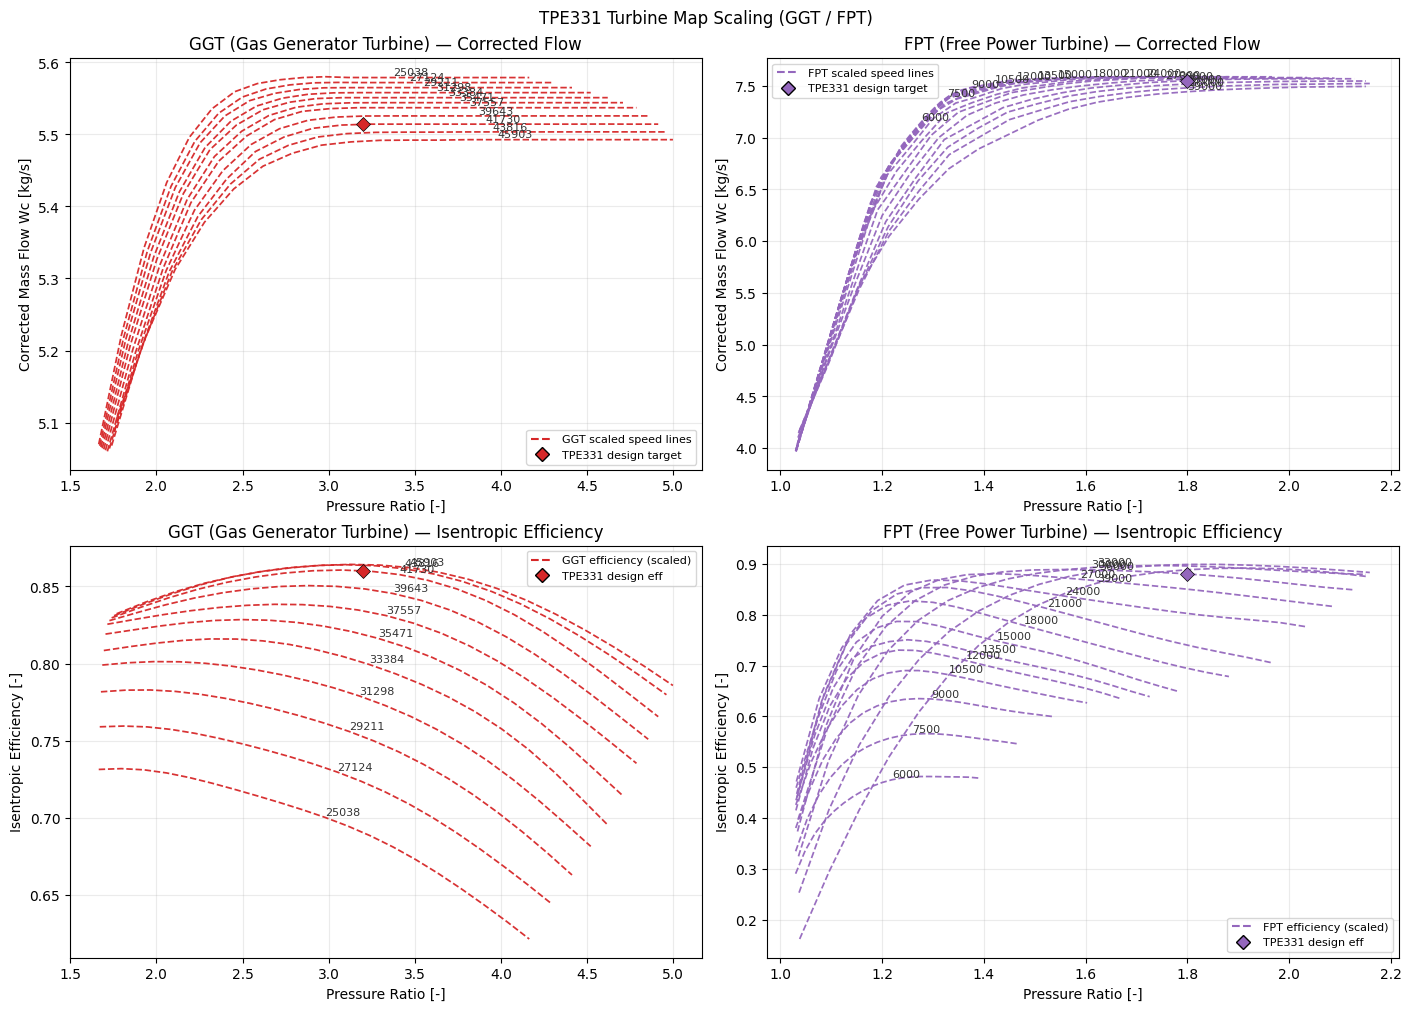

In [19]:
# ─── 5) Turbine 2×2 Plot (GGT / FPT) ───
fig3, axes3 = plot_turbine_maps_2x2(
    scaled_trb,
    suptitle="TPE331 Turbine Map Scaling (GGT / FPT)",
    NmechDes_dict={"GGT": 41730.0, "FPT": 30000.0},
)
print("✓ plot_turbine_maps_2x2() — GGT + FPT")

# Modeling

## 7) Modelica Table Export & .mo Patch (backend packages)

패키지:
- `modelica_table_exporter.py` — 스케일된 맵 → Modelica CombiTable2D `.txt` 파일
- `mo_param_patcher.py` — `.mo` 파일 설계점 파라미터 regex 패치

검증: PropulsionSystem 기존 테이블 포맷과 동일한 구조가 생성되는지 확인

In [29]:
# ─── 6) Modelica Table Export 검증 ───
# PropulsionSystem 패키지 경로 추가
sys.path.insert(0, r"d:\KangDH\ModelicaLib\PropulsionSystem\Jupyter\turbomap")

import modelica_table_exporter
importlib.reload(modelica_table_exporter)
from modelica_table_exporter import (
    export_compressor_tables,
    export_turbine_tables_from_rline,
)

# --- Compressor table export ---
out_cmp = export_compressor_tables(
    nc=scaled["nc"],
    rline=scaled["rline"],  # Rline = column axis
    wc=scaled["wc_scaled_corr"],
    pr=scaled["pr_scaled"],
    eff=scaled["eta_scaled"],
    output_path=r"d:\KangDH\ModelicaLib\PropulsionSystem\tableData\table_Compressor_WcPReff_NcRline_TPE331.txt",
)
print(f"✓ Compressor table exported: {out_cmp}")
print(f"  Shape: nc={len(scaled['nc'])}, rline={len(scaled['rline'])}")
print(f"  → Modelica: Wc_NcRline({len(scaled['nc'])+1},{len(scaled['rline'])+1})")

# --- Turbine table export (GGT) — proper (Nc, Rline)→(Nc, PR) coordinate transform ---
ggt = scaled_trb["GGT"]
result_ggt = export_turbine_tables_from_rline(
    nc=ggt["nc"],
    pr_scaled=ggt["pr_scaled"],   # 2D: (Nc, Rline) → PR at each point
    wc=ggt["wc_scaled_corr"],
    eff=ggt["eta_scaled"],
    output_path=r"d:\KangDH\ModelicaLib\PropulsionSystem\tableData\table_Turbine_WcEff_NcPR_TPE331_GGT.txt",
    n_pr_points=20,
)
print(f"\n✓ GGT turbine table exported: {result_ggt['path']}")
print(f"  PR axis: {result_ggt['pr_axis'].min():.3f} ~ {result_ggt['pr_axis'].max():.3f}")
print(f"  PRtblDes (auto): {result_ggt['pr_des_approx']:.4f}")

# --- Turbine table export (FPT) — same proper transform ---
fpt = scaled_trb["FPT"]
result_fpt = export_turbine_tables_from_rline(
    nc=fpt["nc"],
    pr_scaled=fpt["pr_scaled"],
    wc=fpt["wc_scaled_corr"],
    eff=fpt["eta_scaled"],
    output_path=r"d:\KangDH\ModelicaLib\PropulsionSystem\tableData\table_Turbine_WcEff_NcPR_TPE331_FPT.txt",
    n_pr_points=20,
)
print(f"\n✓ FPT turbine table exported: {result_fpt['path']}")
print(f"  PR axis: {result_fpt['pr_axis'].min():.3f} ~ {result_fpt['pr_axis'].max():.3f}")
print(f"  PRtblDes (auto): {result_fpt['pr_des_approx']:.4f}")

# --- 요약: Modelica에 넣을 PRtblDes 값 ---
print("\n" + "="*60)
print("  Modelica PRtblDes_paramInput (자동 산출)")
print("="*60)
print(f"  GGT: PRtblDes = {result_ggt['pr_des_approx']:.4f}")
print(f"  FPT: PRtblDes = {result_fpt['pr_des_approx']:.4f}")
print(f"  (이 값을 TurboProp_TPE331_ex01.mo에 설정)")

# --- 생성된 파일 첫 5줄 확인 ---
print("\n─── Compressor table (head) ───")
with open(out_cmp) as f:
    for i, line in enumerate(f):
        if i >= 5: break
        print(line.rstrip())

✓ Compressor table exported: d:\KangDH\ModelicaLib\PropulsionSystem\tableData\table_Compressor_WcPReff_NcRline_TPE331.txt
  Shape: nc=10, rline=20
  → Modelica: Wc_NcRline(11,21)

✓ GGT turbine table exported: d:\KangDH\ModelicaLib\PropulsionSystem\tableData\table_Turbine_WcEff_NcPR_TPE331_GGT.txt
  PR axis: 1.665 ~ 5.000
  PRtblDes (auto): 3.3270

✓ FPT turbine table exported: d:\KangDH\ModelicaLib\PropulsionSystem\tableData\table_Turbine_WcEff_NcPR_TPE331_FPT.txt
  PR axis: 1.030 ~ 2.159
  PRtblDes (auto): 1.5813

  Modelica PRtblDes_paramInput (자동 산출)
  GGT: PRtblDes = 3.3270
  FPT: PRtblDes = 1.5813
  (이 값을 TurboProp_TPE331_ex01.mo에 설정)

─── Compressor table (head) ───
#1
double Wc_NcRline(11,21)   # Wc=f(Nc, Rline)
0	0	0.05263	0.10526	0.15789	0.21053	0.26316	0.31579	0.36842	0.42105	0.47368	0.52632	0.57895	0.63158	0.68421	0.73684	0.78947	0.84211	0.89474	0.94737	1
0.5	2.67822859	2.63839873	2.59300193	2.54715388	2.50008106	2.45161586	2.39900445	2.34727746	2.29360887	2.23689251	2.1780

## 8) TPE331 Transient Modelica Model (Turbojet_ex01 기반)

`Turbojet_ex01` 구조를 확장한 2축 터보프롭 모델 (프로펠러 없음):

```
Flt2Fluid → Inlet → Cmp(TPE331) → Comb → GGT → FPT → Nzl
                         ↕ GG shaft        ↕ PT shaft + LoadTorque
```

| 컴포넌트 | 설계점 | 테이블 파일 |
|----------|--------|------------|
| Cmp | 41730rpm, PR=10, η=0.82, 8kg/s | `table_Compressor_WcPReff_NcRline_TPE331.txt` |
| GGT | 41730rpm, T1=1200K, 8.2kg/s | `table_Turbine_WcEff_NcPR_TPE331_GGT.txt` |
| FPT | 30000rpm, T1=1000K, 8.2kg/s | `table_Turbine_WcEff_NcPR_TPE331_FPT.txt` |

**입력 신호:**
- 연료 유량 Ramp: 0.15 → 0.17 kg/s (t=10~15s)
- PT 부하 토크 Ramp: -200 → -700 N⋅m (t=20~25s)

**파일:** `PropulsionSystem/Examples/Engines/Transient/TurboProp_TPE331_ex01.mo`

## 9) Ex01a 결과 검증 (Gas Generator Single-Spool)

`TurboProp_TPE331_ex01a`: Cmp + Comb + GGT + Nzl (FPT 없음, 터보젯 구성)  
`tb_postproc.TBPostProcessor`를 사용하여 결과 로딩 + 플롯 + 파워밸런스 검증.

In [30]:
import sys
sys.path.insert(0, r"D:\KangDH\ModelicaLib\PropulsionSystem\Jupyter\turbomap")
from tb_postproc import TBPostProcessor

# ── TB 연결 & 신호 탐색 ──
pp = TBPostProcessor(
    project=r"E:\KDH\simTemp\TB\Turbo.aedt",
    design="TPE331_ex1a",
    aedt_version="2026.1",
)
pp.connect()
signals = pp.discover_signals()
print(f"\nKey signals: {len(signals)}")
for s in signals[:20]:
    print(f"  {s}")

PyAEDT INFO: Parsing E:\KDH\simTemp\TB\Turbo.aedt.
PyAEDT INFO: Python version 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)].
PyAEDT INFO: PyAEDT version 1.0.0rc2.
PyAEDT INFO: Initializing Desktop session.
PyAEDT INFO: AEDT version 2026.1.
PyAEDT INFO: Found active AEDT gRPC session on port 50051.
PyAEDT INFO: AEDT installation Path C:\Program Files\ANSYS Inc\v261\AnsysEM
PyAEDT INFO: Connected to AEDT gRPC session on port 50051.
PyAEDT INFO: File E:\KDH\simTemp\TB\Turbo.aedt correctly loaded. Elapsed time: 0m 6sec
PyAEDT INFO: Project Turbo set to active.
PyAEDT INFO: Active Design set to 12;TPE331_ex1a
PyAEDT INFO: AEDT objects correctly read
Connected: Turbo / TPE331_ex1a
PyAEDT INFO: Post class has been initialized! Elapsed time: 0m 0sec
Total expressions: 3606
After exclusion: 1610 (removed 1996 internal)
Selected key signals: 137

Key signals: 137
  ExpTurboProp_TPE331_ex1a1.Cmp_CmpTbl_WcPReff_NcRline_y_PR
  ExpTurboProp_TPE331_ex1a1.Cmp_CmpTbl

In [31]:
# ── 시계열 수집 ──
mdf = pp.collect_signals()
print(f"\nColumns ({len(mdf.columns)-1} signals):")
for c in sorted(mdf.columns):
    if c != "time":
        print(f"  {c}")

PyAEDT WARNING: No report category provided. Automatically identified Standard
PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT WARNING: No report category provided. Automatically identified Standard


c:\Users\user\.ansys_python_venvs\pyAEDT_py311\Lib\site-packages\ansys\aedt\core\visualization\post\solution_data.py:648: UserWarning: Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.
  warnings.warn("Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.")


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT WARNING: No report category provided. Automatically identified Standard


c:\Users\user\.ansys_python_venvs\pyAEDT_py311\Lib\site-packages\ansys\aedt\core\visualization\post\solution_data.py:648: UserWarning: Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.
  warnings.warn("Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.")


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT WARNING: No report category provided. Automatically identified Standard


...

c:\Users\user\.ansys_python_venvs\pyAEDT_py311\Lib\site-packages\ansys\aedt\core\visualization\post\solution_data.py:648: UserWarning: Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.
  warnings.warn("Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.")


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
PyAEDT WARNING: No report category provided. Automatically identified Standard


c:\Users\user\.ansys_python_venvs\pyAEDT_py311\Lib\site-packages\ansys\aedt\core\visualization\post\solution_data.py:648: UserWarning: Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.
  warnings.warn("Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.")


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec
PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec
Time axis: ps -> s (span=4.00e+11)
Collected: 416 steps, 137 signals (0 missing)

Columns (137 signals):
  ExpTurboProp_TPE331_ex1a1.Cmp_CmpTbl_WcPReff_NcRline_y_PR
  ExpTurboProp_TPE331_ex1a1.Cmp_CmpTbl_WcPReff_NcRline_y_eff
  ExpTurboProp_TPE331_ex1a1.Cmp_Nc_1
  ExpTurboProp_TPE331_ex1a1.Cmp_NcqNcDes_1
  ExpTurboProp_TPE331_ex1a1.Cmp_Nmech
  ExpTurboProp_TPE331_ex1a1.Cmp_NqNdes
  ExpTurboProp_TPE331_ex1a1.Cmp_PR
  ExpTurboProp_TPE331_ex1a1.Cmp_Rline
  ExpTurboProp_TPE331_ex1a1.Cmp_ScalerDesCmp_CmpTbl_WcPReff_NcRline_Des_y_PR
  ExpTurboProp_TPE331_ex1a1.Cmp_ScalerDesCmp_CmpTbl_WcPReff_NcRline_Des_y_eff
  ExpTurboProp_TPE331_ex1a1.Cmp_SclCmp_u_PR
  ExpTurboProp_TPE331_ex1a1.Cmp_SclCmp_u_eff
  ExpTurboProp_TPE331_ex1a1.Cmp_SclCmp_u_s_PR
  ExpTurboProp_TPE331_ex1a1.Cmp_SclCmp_u_s_eff
  ExpTurboProp_TPE331_ex1a1.Cmp_Wc_1
  ExpTurboProp_TPE331_ex1a1.Cmp_eff
  ExpTurbo

c:\Users\user\.ansys_python_venvs\pyAEDT_py311\Lib\site-packages\ansys\aedt\core\visualization\post\solution_data.py:648: UserWarning: Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.
  warnings.warn("Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.")


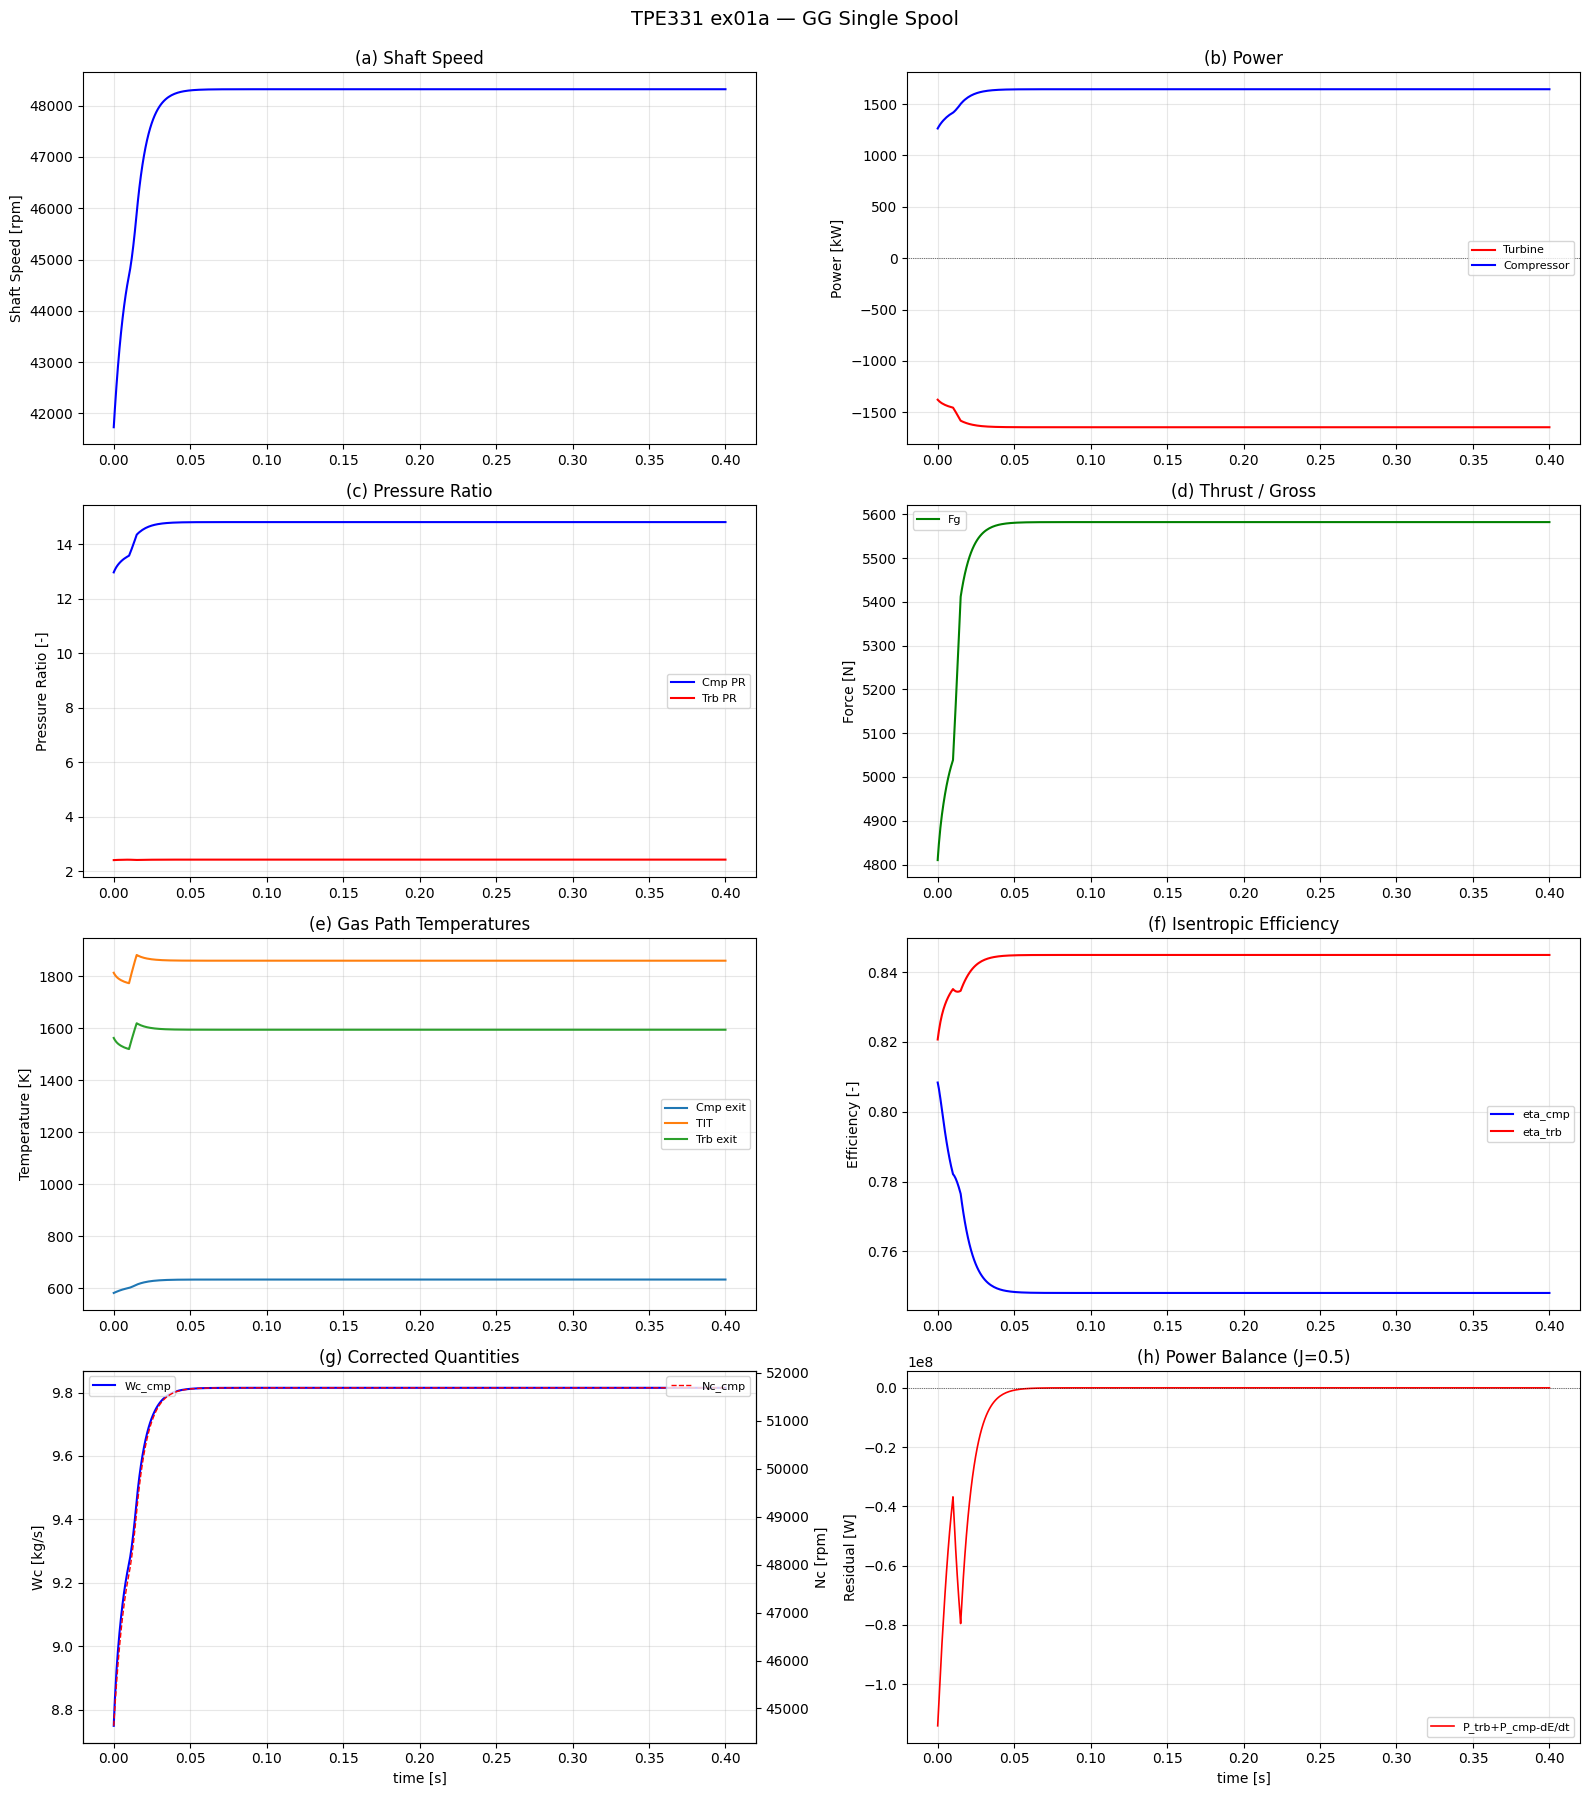

In [32]:
# ── 과도응답 플롯 ──
fig = pp.plot_transient(J_shaft=0.5, title="TPE331 ex01a — GG Single Spool")

In [33]:
# ── 정량 검증: 파워밸런스 & 정상상태 값 ──
vr = pp.verify_power_balance(J_shaft=0.5, ss_fraction=0.1)

# 설계점 비교
print("\n--- Design Point Comparison ---")
des = {"shaft_rpm": 41730.0, "PR_cmp": 10.0, "eff_cmp": 0.82}
for k, v_des in des.items():
    v_sim = vr.steady_state.get(k)
    if v_sim is not None:
        err_pct = (v_sim - v_des) / v_des * 100
        print(f"  {k:14s}: design={v_des:.2f}, sim={v_sim:.2f}, err={err_pct:+.2f}%")

  TPE331_ex1a — Verification Summary
  Time: 0.000 ~ 0.400 s (416 steps)
  SS window: last 41 steps

  Steady-state values:
    shaft_rpm     : 48320.7923
    PR_cmp        : 14.8110
    eff_cmp       : 0.7481
    TIT_K         : 1858.9743
    Fg_N          : 5582.0409
    P_cmp_kW      : 1644.7077
    P_trb_kW      : -1644.7077

  Power balance: 0.0000% [PASS]
  Note: |eps_ss| = 0.0000%

--- Design Point Comparison ---
  shaft_rpm     : design=41730.00, sim=48320.79, err=+15.79%
  PR_cmp        : design=10.00, sim=14.81, err=+48.11%
  eff_cmp       : design=0.82, sim=0.75, err=-8.77%


Wc col: ExpTurboProp_TPE331_ex1a1.Cmp_Wc_1
PR col: ExpTurboProp_TPE331_ex1a1.Cmp_PR
Nc col: ExpTurboProp_TPE331_ex1a1.Cmp_Nc_1


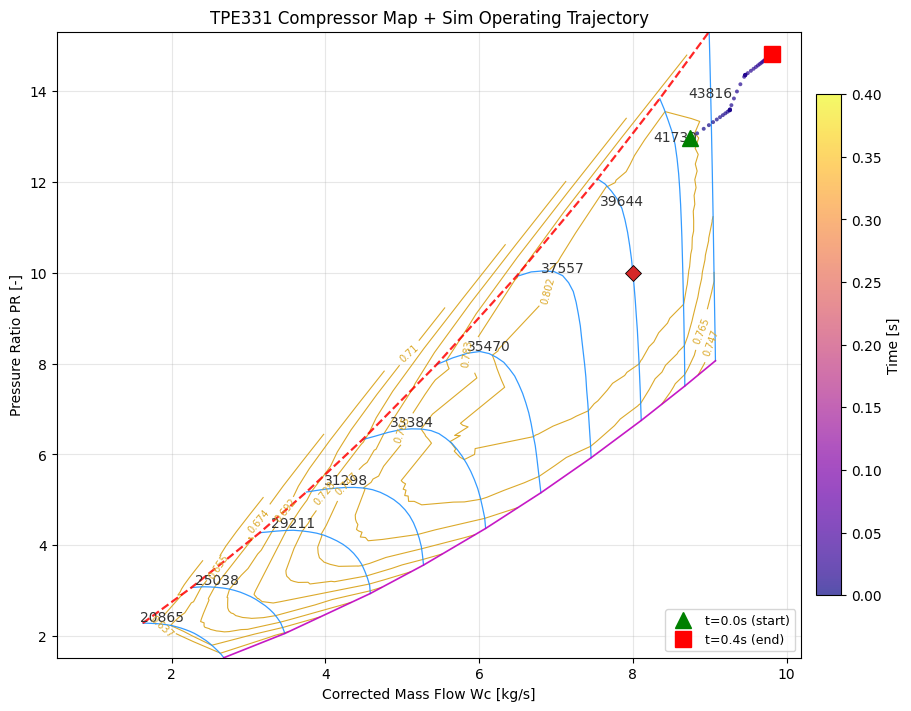

✓ Operating trajectory: Wc=8.75→9.81, PR=12.97→14.81


In [38]:
# ── 컴프레서 맵 + 시뮬레이션 운전 궤적 오버레이 ──
import matplotlib.pyplot as plt
from turbomap_plot_utils import plot_compressor_map

# 시뮬레이션에서 Wc, PR, Nc 추출
col_Wc = pp.find_col(["Cmp_Wc_1", "Cmp_Wc"])
col_PR = pp.find_col(["Cmp_PR"])
col_Nc = pp.find_col(["Cmp_Nc_1", "Cmp_Nc"])

print(f"Wc col: {col_Wc}")
print(f"PR col: {col_PR}")
print(f"Nc col: {col_Nc}")

if col_Wc and col_PR:
    t_sim = mdf["time"].to_numpy()
    Wc_sim = mdf[col_Wc].to_numpy(dtype=float)
    PR_sim = mdf[col_PR].to_numpy(dtype=float)

    # 1) 컴프레서 맵 그리기 (기존 스케일된 맵)
    fig_ov, ax_ov = plot_compressor_map(
        scaled["wc_scaled_corr"],
        scaled["pr_scaled"],
        scaled["eta_scaled"],
        scaled["nc"],
        NmechDes=41730.0,
        design_point={"Wc": scaled["wc_target_corr"], "PR": TPE331_CMP["PRdes"]},
        title="TPE331 Compressor Map + Sim Operating Trajectory",
    )

    # 2) 시뮬레이션 궤적 오버레이 (시간 색상 코딩)
    sc = ax_ov.scatter(
        Wc_sim, PR_sim, c=t_sim, cmap="plasma", s=8, zorder=5, alpha=0.7, edgecolors="none"
    )
    cbar = plt.colorbar(sc, ax=ax_ov, shrink=0.8, pad=0.02)
    cbar.set_label("Time [s]")

    # 시작/종료점 강조
    ax_ov.plot(Wc_sim[0], PR_sim[0], "g^", ms=12, zorder=6, label=f"t={t_sim[0]:.1f}s (start)")
    ax_ov.plot(Wc_sim[-1], PR_sim[-1], "rs", ms=12, zorder=6, label=f"t={t_sim[-1]:.1f}s (end)")
    ax_ov.legend(loc="lower right", fontsize=9)

    plt.show()
    print(f"✓ Operating trajectory: Wc={Wc_sim[0]:.2f}→{Wc_sim[-1]:.2f}, PR={PR_sim[0]:.2f}→{PR_sim[-1]:.2f}")
else:
    print("⚠ Wc_1 또는 PR 컬럼이 mdf에 없습니다. 사용 가능한 컬럼:")
    for c in sorted(mdf.columns):
        if c != "time":
            print(f"  {c}")

GGT Wc col : ExpTurboProp_TPE331_ex1a1.GGT_Wc_1
GGT PR col : ExpTurboProp_TPE331_ex1a1.GGT_PR
GGT Eta col: ExpTurboProp_TPE331_ex1a1.GGT_eff


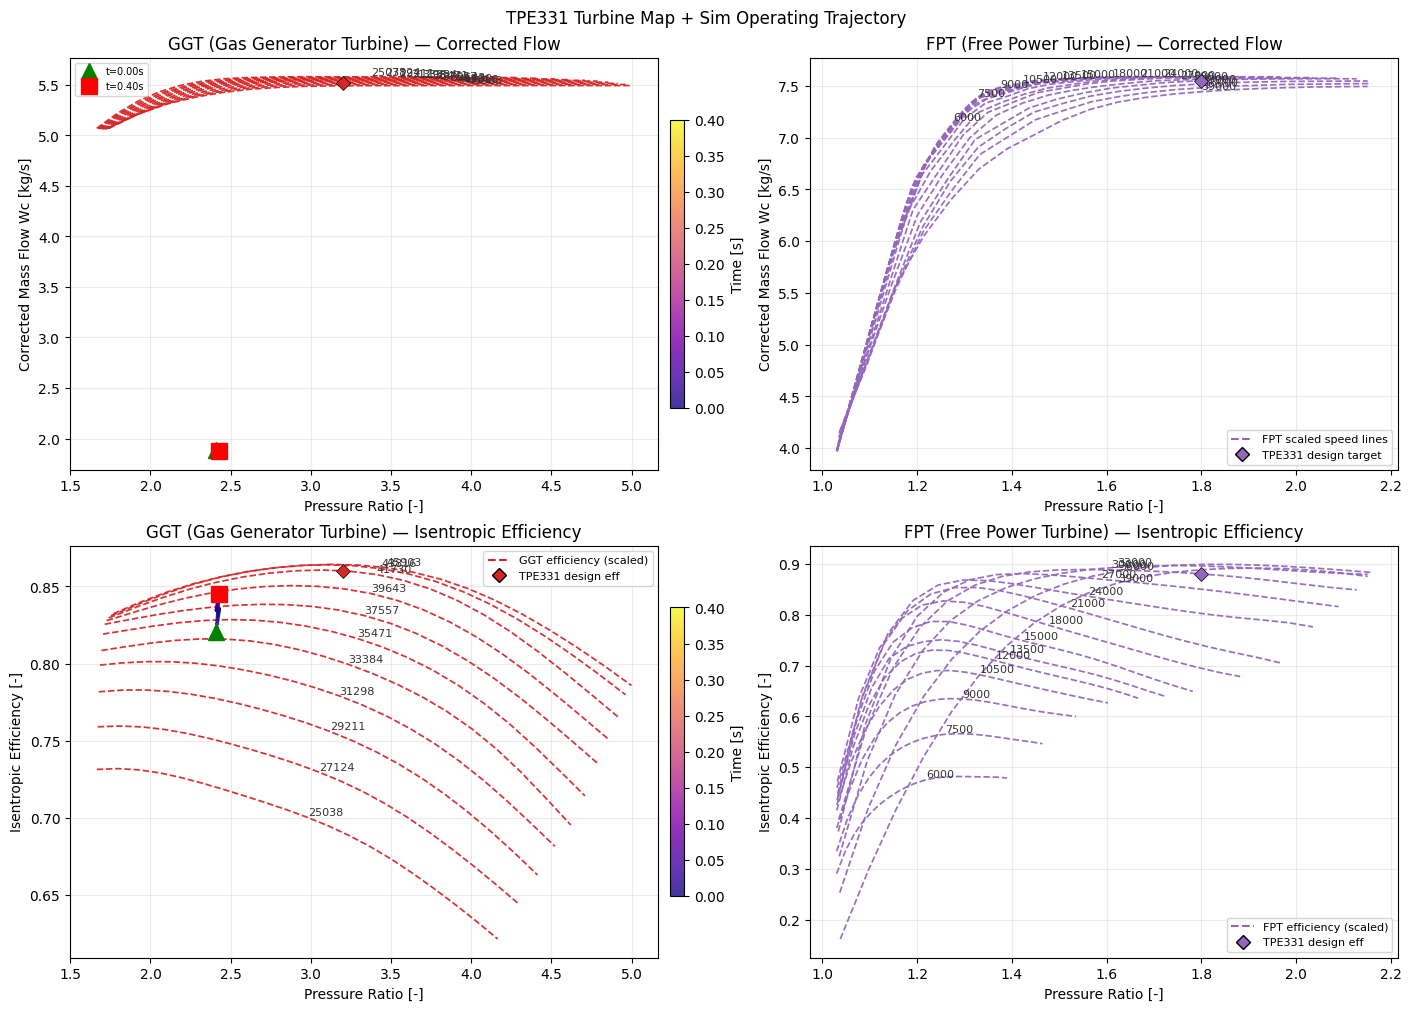

✓ GGT trajectory overlaid: PR=2.41→2.43, Wc=1.883→1.874


In [39]:
# ── GGT 터빈 맵 + 시뮬레이션 운전 궤적 오버레이 (plot_turbine_maps_2x2 재사용) ──
import numpy as np
import matplotlib.pyplot as plt
from turbomap_plot_utils import plot_turbine_maps_2x2

# 시뮬레이션에서 GGT 신호 추출
col_GGT_Wc = pp.find_col(["GGT_Wc_1", "GGT_Wc"])
col_GGT_PR = pp.find_col(["GGT_PR"])
col_GGT_Eta = pp.find_col(["GGT_eff", "GGT_eta"])

print(f"GGT Wc col : {col_GGT_Wc}")
print(f"GGT PR col : {col_GGT_PR}")
print(f"GGT Eta col: {col_GGT_Eta}")

if col_GGT_Wc and col_GGT_PR:
    t_sim = mdf["time"].to_numpy()
    Wc_ggt = mdf[col_GGT_Wc].to_numpy(dtype=float)
    PR_ggt = mdf[col_GGT_PR].to_numpy(dtype=float)
    Eta_ggt = mdf[col_GGT_Eta].to_numpy(dtype=float) if col_GGT_Eta else None

    # 1) 기존 plot_turbine_maps_2x2() 호출 → (fig, axes) 반환
    fig_t, axes_t = plot_turbine_maps_2x2(
        scaled_trb,
        suptitle="TPE331 Turbine Map + Sim Operating Trajectory",
        NmechDes_dict={"GGT": 41730.0, "FPT": 30000.0},
    )

    # 2) GGT axes에 시뮬레이션 궤적 오버레이
    # axes_t[0, col] = Wc vs PR,  axes_t[1, col] = Eta vs PR
    # GGT는 첫 번째 컬럼 (col=0)
    ax_wc = axes_t[0, 0]   # top-left: x=PR, y=Wc
    ax_eta = axes_t[1, 0]  # bottom-left: x=PR, y=Eta

    # Wc trajectory
    sc_wc = ax_wc.scatter(PR_ggt, Wc_ggt, c=t_sim, cmap="plasma", s=10, zorder=6, alpha=0.8, edgecolors="none")
    plt.colorbar(sc_wc, ax=ax_wc, shrink=0.7, pad=0.02, label="Time [s]")
    ax_wc.plot(PR_ggt[0], Wc_ggt[0], "g^", ms=11, zorder=7, label=f"t={t_sim[0]:.2f}s")
    ax_wc.plot(PR_ggt[-1], Wc_ggt[-1], "rs", ms=11, zorder=7, label=f"t={t_sim[-1]:.2f}s")
    ax_wc.legend(loc="best", fontsize=7)

    # Eta trajectory (if available)
    if Eta_ggt is not None:
        sc_eta = ax_eta.scatter(PR_ggt, Eta_ggt, c=t_sim, cmap="plasma", s=10, zorder=6, alpha=0.8, edgecolors="none")
        plt.colorbar(sc_eta, ax=ax_eta, shrink=0.7, pad=0.02, label="Time [s]")
        ax_eta.plot(PR_ggt[0], Eta_ggt[0], "g^", ms=11, zorder=7)
        ax_eta.plot(PR_ggt[-1], Eta_ggt[-1], "rs", ms=11, zorder=7)

    plt.show()
    print(f"✓ GGT trajectory overlaid: PR={PR_ggt[0]:.2f}→{PR_ggt[-1]:.2f}, Wc={Wc_ggt[0]:.3f}→{Wc_ggt[-1]:.3f}")
else:
    print("⚠ GGT_Wc 또는 GGT_PR 컬럼 없음. 사용 가능:")
    for c in sorted(mdf.columns):
        if "GGT" in c.upper():
            print(f"  {c}")